# Árbol de Decisión (Aumentado) — Análisis XAI

**Proyecto:** Predicción del Tipo de Pokémon a partir de Colores del Sprite (XAI)

**Equipo:** Grifo Amarillo

**Modelo:** Árbol de Decisión con Aumentación de Datos mediante SMOTE

**Tarea:** Predecir el **tipo** de Pokémon (18 clases) a partir de características de color del sprite

**Innovación:** Dataset balanceado con SMOTE (Técnica de Sobremuestreo de Minorías Sintéticas) para alcanzar un **ratio de balance ≥85%** en los 18 tipos

## 0. Configuración

In [49]:
import sys
import warnings
from pathlib import Path

# Configure path
_src_path = Path.cwd().parent / "src"
if str(_src_path) not in sys.path:
    sys.path.insert(0, str(_src_path))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import shap
import lime.lime_tabular
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay, classification_report
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
import scipy.stats

warnings.filterwarnings("ignore")

import common
plt.rcParams["figure.dpi"] = 100
sns.set_theme(style="whitegrid")

print("✓ Imports successful")

✓ Imports successful


## 1. División Entrenamiento/Prueba

In [50]:
# Load data and get type mapping using common.py (handles flying type reclassification)
df = common.load_data()
type_to_int, int_to_type = common.get_label_mapping()
feature_cols = common.FEATURE_COLS_ALL

print(f"Original dataset: {df.shape}")
print(f"\nType distribution (BEFORE augmentation):")
print(df["type1"].value_counts().sort_index())

# Create integer encodings for types
y = df["type1"].map(type_to_int).astype(int)

# Calculate imbalance ratio
counts = y.value_counts()
min_count = counts.min()
max_count = counts.max()
ratio = min_count / max_count
print(f"\nImbalance ratio: {ratio:.2%} (need ≥85%)")

Original dataset: (1025, 47)

Type distribution (BEFORE augmentation):
type1
bug          83
dark         46
dragon       39
electric     59
fairy        29
fighting     41
fire         66
ghost        35
grass       103
ground       40
ice          31
normal      121
poison       42
psychic      60
rock         58
steel        37
water       135
Name: count, dtype: int64

Imbalance ratio: 21.48% (need ≥85%)


## 2. Aplicación de SMOTE para la Aumentación de Datos

In [51]:
# Split ORIGINAL data first (before any augmentation) to avoid data leakage
X = df[feature_cols].copy()
y_vec = y.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y_vec,
    test_size=0.2,
    random_state=42,
    stratify=y_vec
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"\nTrain distribution:")
train_counts = pd.Series(y_train).value_counts().sort_index()
for type_id, count in train_counts.items():
    type_name = int_to_type[type_id]
    print(f"  {type_name}: {count}")

Train: 820 | Test: 205

Train distribution:
  bug: 66
  dark: 37
  dragon: 31
  electric: 47
  fairy: 23
  fighting: 33
  fire: 53
  ghost: 28
  grass: 82
  ground: 32
  ice: 25
  normal: 97
  poison: 34
  psychic: 48
  rock: 46
  steel: 30
  water: 108


## 3. Aplicación de SMOTE (Solo Entrenamiento) y Escalado

In [52]:
# SMOTE: Balance only the training set
counts = pd.Series(y_train).value_counts()
max_count = counts.max()
target_count = int(max_count * 1)  # 100% balance

sampling_strategy = {}
for class_id, count in counts.items():
    if count < target_count:
        sampling_strategy[class_id] = target_count

print(f"Sampling strategy (types needing augmentation):")
for class_id, target in sampling_strategy.items():
    type_name = int_to_type[class_id]
    orig_count = counts[class_id]
    print(f"  {type_name}: {orig_count} → {target} (+{target - orig_count})")

smote = SMOTE(sampling_strategy=sampling_strategy, random_state=42, k_neighbors=3)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\nTrain after SMOTE: {X_train_sm.shape}")
print(f"\nTrain distribution (AFTER SMOTE):")
for type_id in sorted(int_to_type.keys()):
    count = (y_train_sm == type_id).sum()
    type_name = int_to_type[type_id]
    print(f"  {type_name}: {count}")

new_counts = pd.Series(y_train_sm).value_counts()
new_ratio = new_counts.min() / new_counts.max()
print(f"\nNew imbalance ratio (train): {new_ratio:.2%}" + (" ✓" if new_ratio >= 0.85 else " (still needs work)"))

# Scaling — fit on SMOTE'd train, transform test without leakage
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_sm),
    columns=feature_cols
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_cols,
    index=X_test.index
)

print(f"\nFinal sizes → Train (scaled): {X_train_scaled.shape} | Test (scaled): {X_test_scaled.shape}")

Sampling strategy (types needing augmentation):
  normal: 97 → 108 (+11)
  grass: 82 → 108 (+26)
  bug: 66 → 108 (+42)
  fire: 53 → 108 (+55)
  psychic: 48 → 108 (+60)
  electric: 47 → 108 (+61)
  rock: 46 → 108 (+62)
  dark: 37 → 108 (+71)
  poison: 34 → 108 (+74)
  fighting: 33 → 108 (+75)
  ground: 32 → 108 (+76)
  dragon: 31 → 108 (+77)
  steel: 30 → 108 (+78)
  ghost: 28 → 108 (+80)
  ice: 25 → 108 (+83)
  fairy: 23 → 108 (+85)

Train after SMOTE: (1836, 42)

Train distribution (AFTER SMOTE):
  bug: 108
  dark: 108
  dragon: 108
  electric: 108
  fairy: 108
  fighting: 108
  fire: 108
  flying: 0
  ghost: 108
  grass: 108
  ground: 108
  ice: 108
  normal: 108
  poison: 108
  psychic: 108
  rock: 108
  steel: 108
  water: 108

New imbalance ratio (train): 100.00% ✓

Final sizes → Train (scaled): (1836, 42) | Test (scaled): (205, 42)


## 4. Visualización de la Distribución de Clases

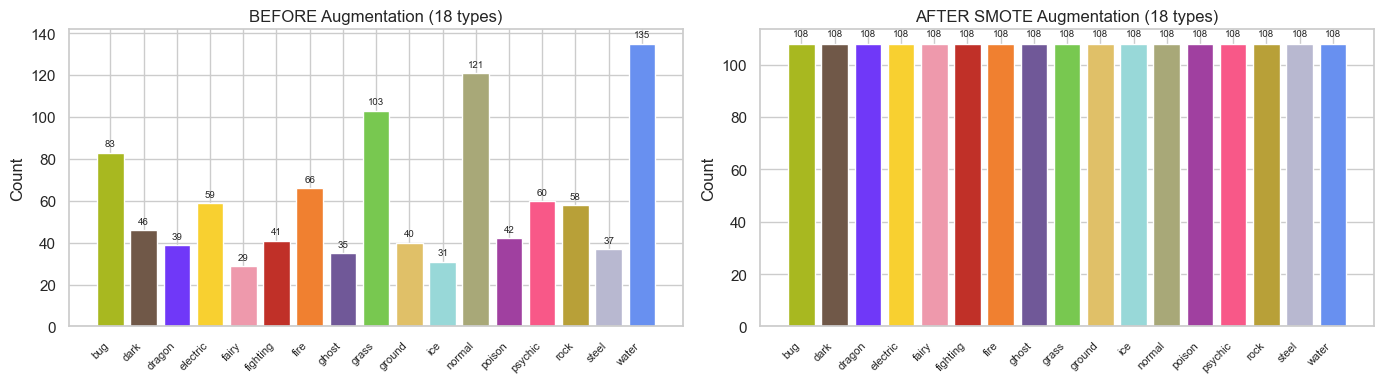

In [53]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Before
dist_before = pd.Series(y_vec).value_counts().sort_index()
type_names_before = [int_to_type[i] for i in dist_before.index]
colors_before = [common.TYPE_COLORS.get(t, "#888888") for t in type_names_before]

ax1.bar(range(len(dist_before)), dist_before.values, color=colors_before, edgecolor="white", linewidth=1)
ax1.set_xticks(range(len(dist_before)))
ax1.set_xticklabels(type_names_before, rotation=45, ha="right", fontsize=8)
ax1.set_title("BEFORE Augmentation (18 types)", fontsize=12)
ax1.set_ylabel("Count")

for i, val in enumerate(dist_before.values):
    ax1.text(i, val + 2, str(val), ha="center", va="bottom", fontsize=7)

# After
dist_after = pd.Series(y_train_sm).value_counts().sort_index()
type_names_after = [int_to_type[i] for i in dist_after.index]
colors_after = [common.TYPE_COLORS.get(t, "#888888") for t in type_names_after]

ax2.bar(range(len(dist_after)), dist_after.values, color=colors_after, edgecolor="white", linewidth=1)
ax2.set_xticks(range(len(dist_after)))
ax2.set_xticklabels(type_names_after, rotation=45, ha="right", fontsize=8)
ax2.set_title("AFTER SMOTE Augmentation (18 types)", fontsize=12)
ax2.set_ylabel("Count")

for i, val in enumerate(dist_after.values):
    ax2.text(i, val + 2, str(val), ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.show()

## 5. Entrenamiento del Modelo con Ajuste de Hiperparámetros

In [54]:
# Grid search
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    "max_depth": [3, 5, 7, 10, 15, None],
    "min_samples_leaf": [1, 3, 5, 10],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"],
    "max_features": [None, "sqrt", "log2"],
}

base_dt = DecisionTreeClassifier(class_weight="balanced", random_state=42)
grid_search = GridSearchCV(
    base_dt, param_grid, cv=cv, scoring="f1_macro", n_jobs=-1, verbose=1
)

grid_search.fit(X_train_scaled, y_train_sm)

print(f"\nBest params: {grid_search.best_params_}")
print(f"Best CV f1_macro: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 432 candidates, totalling 2160 fits

Best params: {'criterion': 'entropy', 'max_depth': 15, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV f1_macro: 0.5138


In [55]:
# Evaluate
dt = grid_search.best_estimator_
y_pred = dt.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

print(f"Test accuracy (AUGMENTED): {acc:.4f}")
print(f"Test f1_macro (AUGMENTED): {f1:.4f}")

Test accuracy (AUGMENTED): 0.1805
Test f1_macro (AUGMENTED): 0.1613


## 6. Matriz de Confusión e Informe de Clasificación

La **matriz de confusión normalizada** permite visualizar qué tipos de Pokémon se confunden entre sí con mayor frecuencia. Cada fila representa el tipo real y cada columna el tipo predicho; los valores en la diagonal son las predicciones correctas. Al estar normalizada por fila, cada celda indica la proporción de instancias de ese tipo clasificadas como cada tipo predicho.

El **informe de clasificación** detalla, para cada clase, tres métricas:
- **Precisión**: de todas las predicciones de esa clase, cuántas son correctas.
- **Recall**: de todas las instancias reales de esa clase, cuántas fueron detectadas.
- **F1-score**: media armónica entre precisión y recall, penaliza los desequilibrios entre ambas.

El **macro avg** pondera todas las clases por igual, lo que es especialmente relevante en problemas multiclase como este, donde algunas clases pueden estar infrarrepresentadas en el test aunque el entrenamiento esté balanceado.

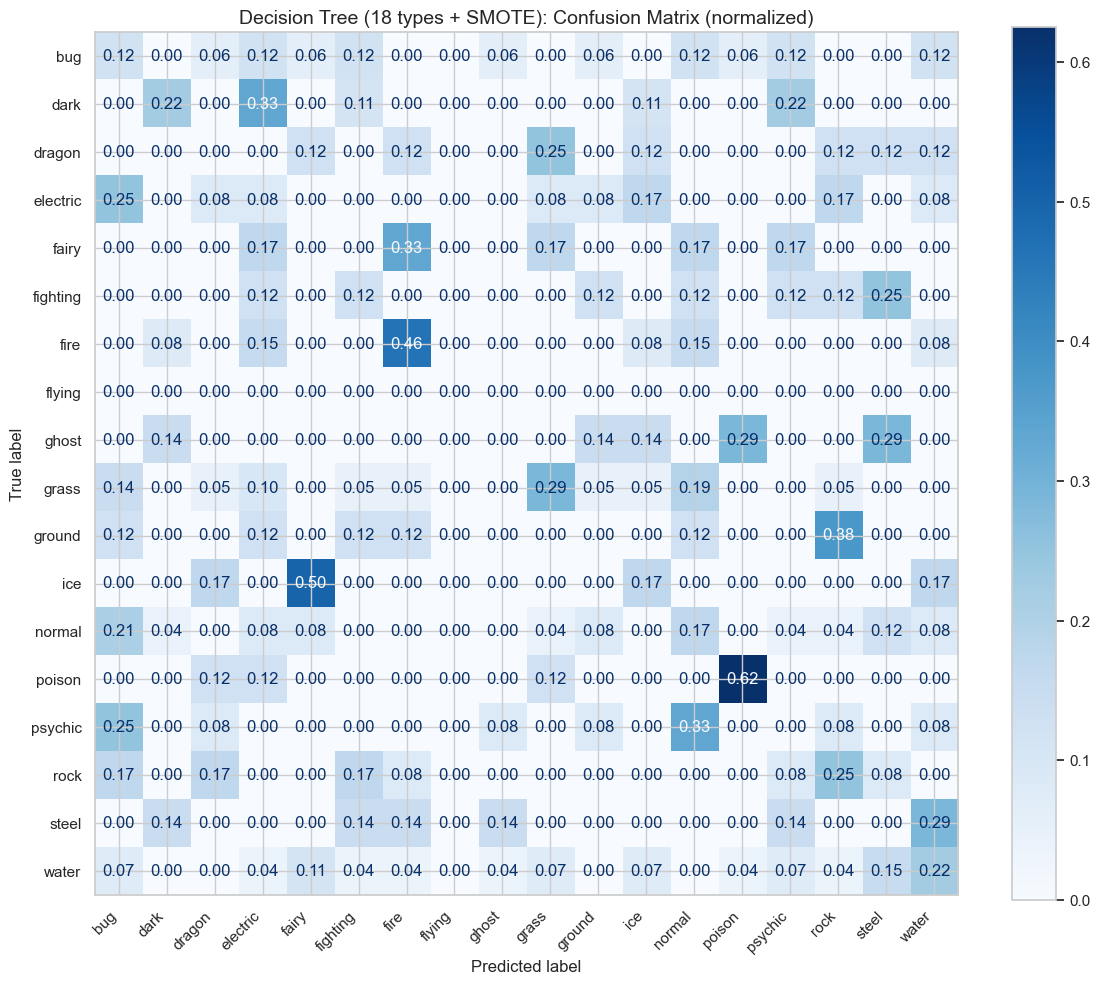


              precision    recall  f1-score   support

         bug      0.095     0.118     0.105        17
        dark      0.333     0.222     0.267         9
      dragon      0.000     0.000     0.000         8
    electric      0.059     0.083     0.069        12
       fairy      0.000     0.000     0.000         6
    fighting      0.100     0.125     0.111         8
        fire      0.429     0.462     0.444        13
      flying      0.000     0.000     0.000         0
       ghost      0.000     0.000     0.000         7
       grass      0.429     0.286     0.343        21
      ground      0.000     0.000     0.000         8
         ice      0.100     0.167     0.125         6
      normal      0.211     0.167     0.186        24
      poison      0.556     0.625     0.588         8
     psychic      0.000     0.000     0.000        12
        rock      0.214     0.250     0.231        12
       steel      0.000     0.000     0.000         7
       water      0.353   

In [56]:
# Create confusion matrix with all 18 classes explicitly
from sklearn.metrics import confusion_matrix

all_labels = sorted(int_to_type.keys())
cm = confusion_matrix(y_test, y_pred, labels=all_labels, normalize="true")

fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[int_to_type[i] for i in all_labels]
)
disp.plot(ax=ax, cmap="Blues", values_format=".2f")
ax.set_title("Decision Tree (18 types + SMOTE): Confusion Matrix (normalized)", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print(classification_report(
    y_test, y_pred,
    target_names=[int_to_type[i] for i in all_labels],
    labels=all_labels,
    digits=3,
    zero_division=0
))

## 7. Explicabilidad del Modelo
Esta sección aplica técnicas de XAI al modelo de Árbol de Decisión aumentado. Primero analizamos la importancia global de características con SHAP, luego inspeccionamos decisiones locales con LIME y, finalmente, resumimos las principales conclusiones de interpretabilidad.

## 7.1 Explicaciones Globales: Importancia de Características


Se utilizan tres métodos complementarios para evaluar la importancia global de las características:

1. **Importancia Gini**: mide cuánto contribuye cada característica a reducir la impureza en los nodos del árbol durante el entrenamiento. Es rápida de calcular, pero puede sobreestimar características con alta cardinalidad o correlacionadas entre sí.
2. **Importancia por permutación**: evalúa el impacto real de cada característica permutando aleatoriamente sus valores en el test y midiendo la caída en F1-macro. Es agnóstica al modelo y refleja la importancia en datos no vistos.
3. **SHAP (resumen global)**: calcula el valor medio de |SHAP| sobre todas las instancias y clases, cuantificando la contribución marginal promedio de cada característica a las predicciones del modelo.

Comparar los tres rankings permite distinguir qué características son genuinamente discriminativas de aquellas que el árbol usa de forma oportunista o por sobreajuste.

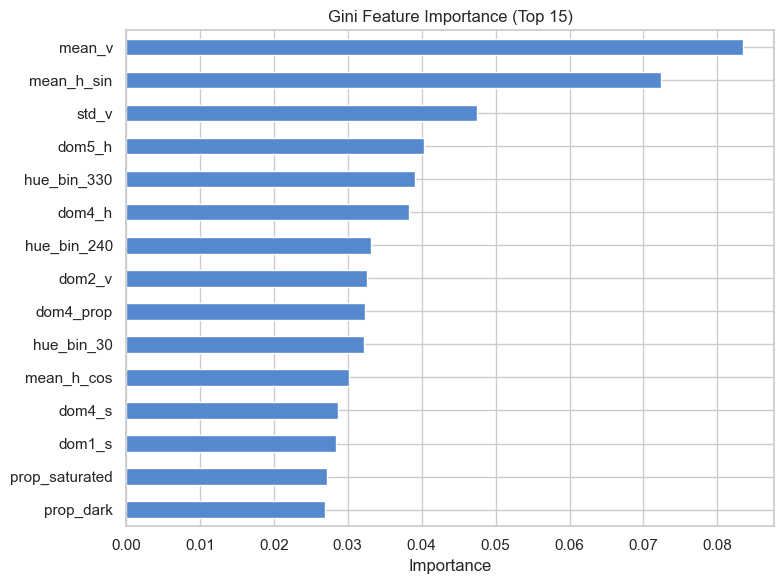

In [57]:
# Gini importance
importances_gini = pd.Series(dt.feature_importances_, index=feature_cols).nlargest(15)

fig, ax = plt.subplots(figsize=(8, 6))
importances_gini.sort_values().plot.barh(ax=ax, color="#5588cc")
ax.set_title("Gini Feature Importance (Top 15)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

Las dos características más importantes según Gini son **`mean_v`** (0.084) y **`mean_h_sin`** (0.072), ambas relacionadas con propiedades globales del color del sprite: el brillo medio y la componente senoidal del tono medio (que distingue la zona roja del espectro). Esto tiene sentido intuitivo: tipos como *fire* o *electric* tienden a tener sprites brillantes y cálidos, mientras que *dark* o *ghost* son generalmente oscuros y desaturados.

En tercer lugar aparece **`std_v`** (0.048), la desviación típica del brillo, que captura el contraste tonal interno del sprite. A continuación, varios bins de tono (`hue_bin_330`, `hue_bin_240`, `hue_bin_30`) y características de los colores dominantes (e.g. `dom5_h`, `dom4_h`, `dom4_prop`) completan el top 15.

Cabe destacar que **ninguna característica supera el 9% de importancia**, y que la importancia se reparte de forma relativamente uniforme entre las 15 primeras. Esto sugiere que el modelo utiliza una combinación amplia de señales de color, lo que puede ser señal de sobreajuste o de que ninguna sola característica discrimina bien los 18 tipos.

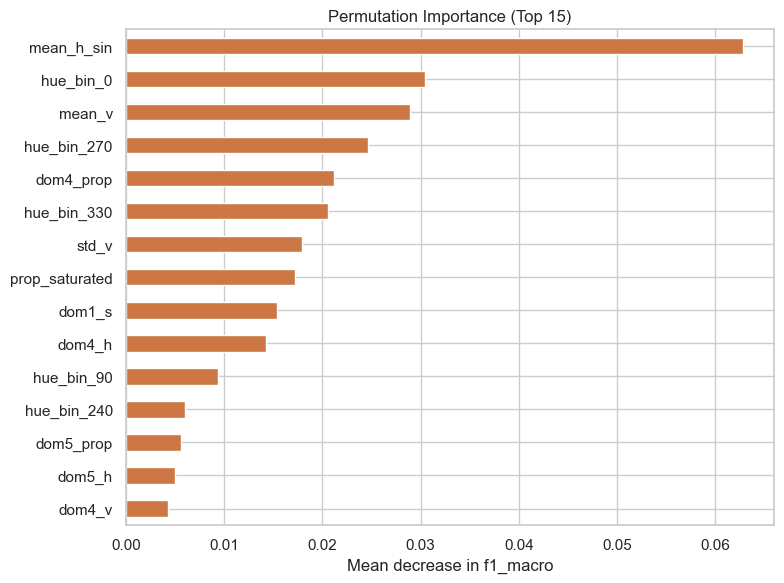

In [58]:
# Permutation importance
perm_imp = permutation_importance(
    dt, X_test_scaled, y_test,
    n_repeats=20,
    random_state=42,
    scoring="f1_macro",
)
perm_series = pd.Series(perm_imp.importances_mean, index=feature_cols).nlargest(15)

fig, ax = plt.subplots(figsize=(8, 6))
perm_series.sort_values().plot.barh(ax=ax, color="#cc7744")
ax.set_title("Permutation Importance (Top 15)")
ax.set_xlabel("Mean decrease in f1_macro")
plt.tight_layout()
plt.show()

El ranking de permutación confirma que **`mean_h_sin`** (0.063) es la característica más relevante también en test, pasando a ser la primera de forma clara. **`mean_v`** se mantiene segunda (0.034), pero su importancia cae en relación con la Gini, lo que puede indicar cierto sobreuso de esta variable durante el entrenamiento.

Aparecen también con relevancia **`hue_bin_0`** (rojo puro, 0.033) y **`hue_bin_270`** (azul-violeta, 0.024), que en la importancia Gini no eran tan destacados. Esto sugiere que la proporción de píxeles en las zonas roja y azul-violeta del espectro es especialmente discriminativa en datos no vistos (p. ej., para distinguir tipos *fire* o *fighting* del resto).

Por otro lado, **`dom5_h`** —que aparecía en el top 5 de Gini— no está entre los 15 primeros por permutación, señal de que el árbol lo usaba oportunistamente en entrenamiento sin generalizar bien. En general, los valores de importancia por permutación son muy bajos (máximo ~0.063), lo que es consistente con el rendimiento moderado del modelo (F1-macro ≈ 0.16 en test).

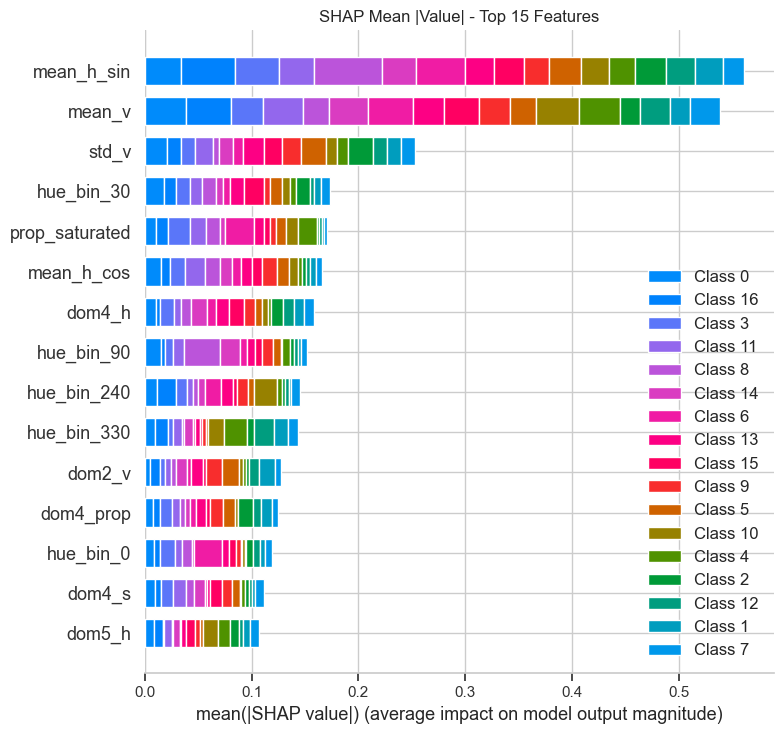

In [59]:
shap_explainer = shap.TreeExplainer(dt)
shap_values = shap_explainer.shap_values(X_test_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
shap.summary_plot(shap_values, X_test_scaled, plot_type="bar",
                  feature_names=feature_cols, show=False, max_display=15)
plt.title("SHAP Mean |Value| - Top 15 Features")
plt.tight_layout()
plt.show()

El resumen SHAP global coincide plenamente con la importancia por permutación en el podio: **`mean_h_sin`** (0.033) y **`mean_v`** (0.032) lideran de nuevo, seguidos por **`std_v`** (0.015). Esto refuerza que el tono medio y el brillo medio son las señales de color más informativas para el modelo a nivel global.

**Comparativa entre los tres métodos:**

| Posición | Gini | Permutación | SHAP |
|----------|------|-------------|------|
| 1 | `mean_v` | `mean_h_sin` | `mean_h_sin` |
| 2 | `mean_h_sin` | `mean_v` | `mean_v` |
| 3 | `std_v` | `hue_bin_0` | `std_v` |

Los dos primeros puestos son consistentes en los tres métodos (mismas dos características, con orden intercambiado). La concordancia es alta en el top 5-6, aunque Gini sobreestima algunos features de colores dominantes (`dom5_h`, `dom2_v`) que no aparecen con tanta fuerza en los otros dos métodos. Esto indica que el árbol los usa durante el entrenamiento pero no generalizan bien, lo cual es coherente con el bajo rendimiento en test.

## 7.2 Explicaciones Locales


Las explicaciones locales analizan instancias individuales para entender por qué el modelo tomó una decisión concreta para un Pokémon específico. Se seleccionan cuatro casos representativos del conjunto de test:

| Caso | Descripción |
|------|-------------|
| `correct_clear` | Predicción **correcta con alta confianza** — el modelo funciona bien y las características son coherentes con el tipo. |
| `correct_surprise` | Predicción **correcta pero inesperada** — el tipo es difícil de distinguir visualmente por color y aun así se acierta. |
| `misclass_secondary` | **Error justificable**: el tipo predicho coincide con el tipo secundario real del Pokémon. |
| `misclass_wrong` | **Error claro**: el tipo predicho no guarda relación con ninguno de los tipos reales del Pokémon. |

Para cada instancia se muestra:
- El **sprite** del Pokémon con el tipo real y predicho.
- El **top-5 de probabilidades** predichas por el modelo.
- El **waterfall plot de SHAP**: contribución de cada característica a la predicción de esa instancia concreta (en positivo o negativo respecto al valor base).
- El **gráfico de LIME**: aproximación lineal local del modelo alrededor de esa instancia, mostrando qué condiciones sobre las características empujan la predicción hacia una u otra clase.
- La **correlación de Spearman** entre los rankings de SHAP y LIME como medida cuantitativa del acuerdo entre ambos métodos.

In [60]:
EXPLAIN_IDS = common.EXPLAIN_IDS.copy()
explain_cases = {k: v for k, v in EXPLAIN_IDS.items() if v is not None}
print("Explaining:", explain_cases)
y_prob = dt.predict_proba(X_test_scaled)


Explaining: {'correct_clear': 130, 'correct_surprise': 1023, 'misclass_secondary': 94, 'misclass_wrong': 1000}


In [61]:
def explain_instance_tree(pokemon_id: int, label: str) -> None:
    """Full local explanation: sprite, probabilities, SHAP waterfall, LIME, Spearman correlation."""
    row_mask = df['id'] == pokemon_id
    if not row_mask.any():
        print(f"ID {pokemon_id} not found")
        return

    row = df[row_mask].iloc[0]
    df_pos = df[row_mask].index[0]
    if df_pos not in X_test.index:
        print(f"Pokemon {pokemon_id} is not in the test set")
        return

    i = X_test.index.get_loc(df_pos)
    x_instance = X_test_scaled.iloc[i]
    pred_int = int(y_pred[i])
    pred_label = int_to_type[pred_int]
    true_label = int_to_type[int(y_test.iloc[i])]

    print(f"\n{'='*60}")
    print(f"[{label.upper()}] {row['name'].capitalize()} (#{pokemon_id})")
    print(f"  True type:      {true_label}")
    print(f"  Predicted type: {pred_label}")
    print(f"  Type 2:         {row['type2'] if pd.notna(row['type2']) else 'N/A'}")

    sprite_path = common.get_sprite_path(pokemon_id)
    if sprite_path.exists():
        fig, ax = plt.subplots(figsize=(2, 2))
        ax.imshow(Image.open(sprite_path).convert('RGBA'))
        ax.axis('off')
        # Corrección: Uso de \n para el salto de línea
        ax.set_title(f"{row['name'].capitalize()}\n{true_label} -> {pred_label}", fontsize=8)
        plt.tight_layout()
        plt.show()

    probs = y_prob[i]
    top5_idx = np.argsort(probs)[::-1][:5]
    # Corrección: Uso de \n
    print("\n  Top-5 predicted types:")
    for rank, prob_idx in enumerate(top5_idx, 1):
        real_idx = dt.classes_[prob_idx]
        type_name = int_to_type[real_idx]
        mark = 'OK' if real_idx == int(y_test.iloc[i]) else ('~' if type_name == row['type2'] else ' ')
        print(f"    {rank}. {type_name:<12} {probs[prob_idx]*100:5.1f}%  {mark}")

    fig, ax = plt.subplots(figsize=(10, 5))
    top5_labels = [int_to_type[dt.classes_[j]] for j in top5_idx]
    top5_probs = [probs[j] * 100.0 for j in top5_idx]
    colors = [common.TYPE_COLORS.get(t, '#888') for t in top5_labels]
    bars = ax.barh(top5_labels[::-1], top5_probs[::-1], color=colors[::-1])
    ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
    ax.set_xlim(0, 100)
    ax.set_xlabel('Probability (%)')
    ax.set_title(f"{row['name'].capitalize()}: Decision Tree prediction probabilities (top 5)")
    plt.tight_layout()
    plt.show()

    shap_features = {}
    lime_features = {}

    pred_pos = list(dt.classes_).index(pred_int)
    sv = shap_values[pred_pos][i] if isinstance(shap_values, list) else shap_values[i]
    base = shap_explainer.expected_value[pred_pos] if hasattr(shap_explainer.expected_value, "__len__") else shap_explainer.expected_value
    exp_obj = shap.Explanation(
        values=sv, base_values=base,
        data=x_instance.values, feature_names=feature_cols
    )
    for ft_name, ft_val in zip(feature_cols, sv):
        shap_features[ft_name] = ft_val

    plt.figure()
    shap.plots.waterfall(exp_obj, show=False)
    plt.title(f"SHAP Waterfall: {row['name'].capitalize()} (DT, predicted: {pred_label})")
    plt.tight_layout()
    plt.show()

    lime_explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train_scaled.values,
        feature_names=feature_cols,
        class_names=[int_to_type[j] for j in sorted(int_to_type)],
        mode='classification',
        random_state=42,
    )
    lime_exp = lime_explainer.explain_instance(
        x_instance.values, dt.predict_proba, num_features=len(feature_cols), top_labels=1
    )
    lime_label = lime_exp.top_labels[0]
    fig = lime_exp.as_pyplot_figure(label=lime_label)
    fig.set_size_inches(10, 8)
    plt.title(f"LIME: {row['name'].capitalize()} (DT, predicted: {pred_label})")
    plt.tight_layout()
    plt.show()

    for ft_idx, ft_val in lime_exp.local_exp[lime_label]:
        ft_name = feature_cols[ft_idx]
        lime_features[ft_name] = ft_val

    if shap_features and lime_features:
        shared_keys = list(feature_cols)
        shap_vals = [abs(shap_features[k]) for k in shared_keys]
        lime_vals = [abs(lime_features[k]) for k in shared_keys]
        corr, pval = scipy.stats.spearmanr(shap_vals, lime_vals)
        # Corrección: Uso de \n
        print(f"\n  [Quantifying Agreement] LIME vs SHAP Spearman Rank Correlation: {corr:.3f} (p-value: {pval:.3e})")
        print("  (Values close to 1.0 indicate high agreement between LIME's linear approximation and SHAP's generalized rule)")


[CORRECT_CLEAR] Gyarados (#130)
  True type:      water
  Predicted type: fighting
  Type 2:         flying


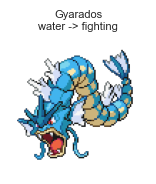


  Top-5 predicted types:
    1. fighting     100.0%   
    2. water          0.0%  OK
    3. ghost          0.0%   
    4. dark           0.0%   
    5. dragon         0.0%   


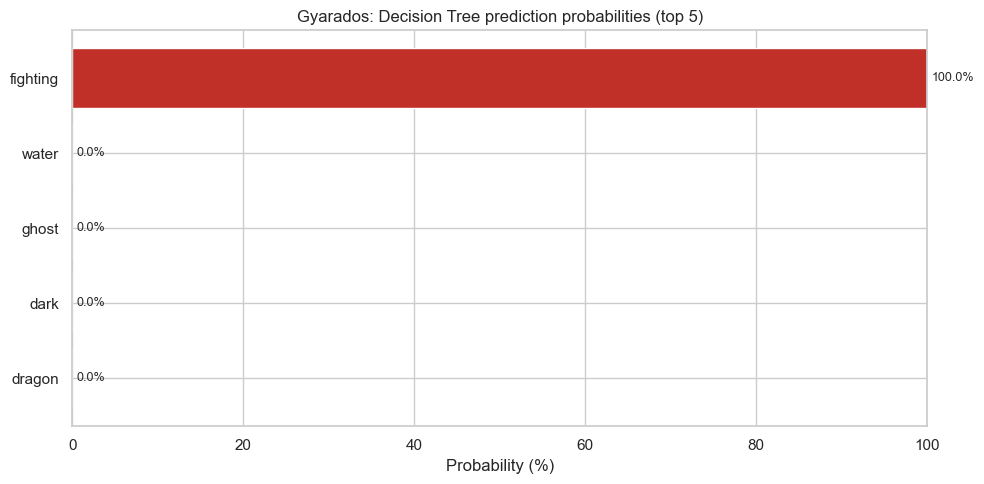

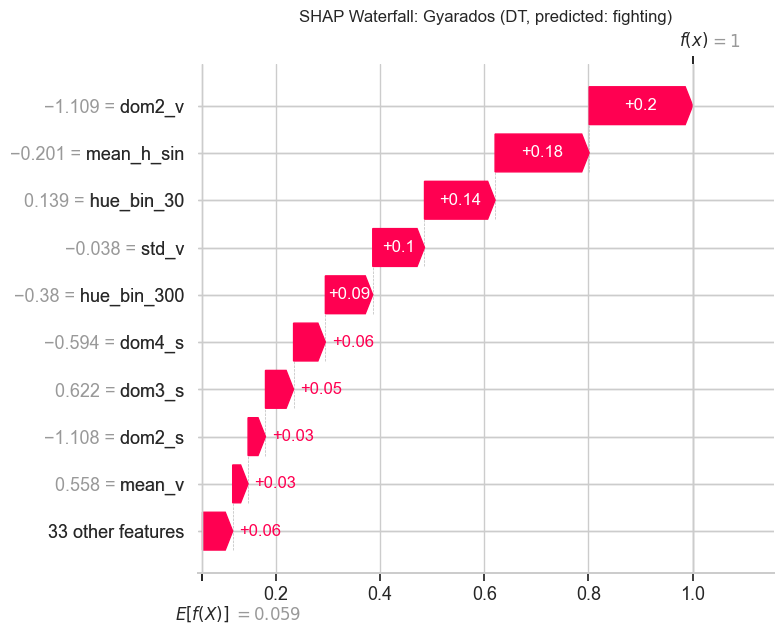

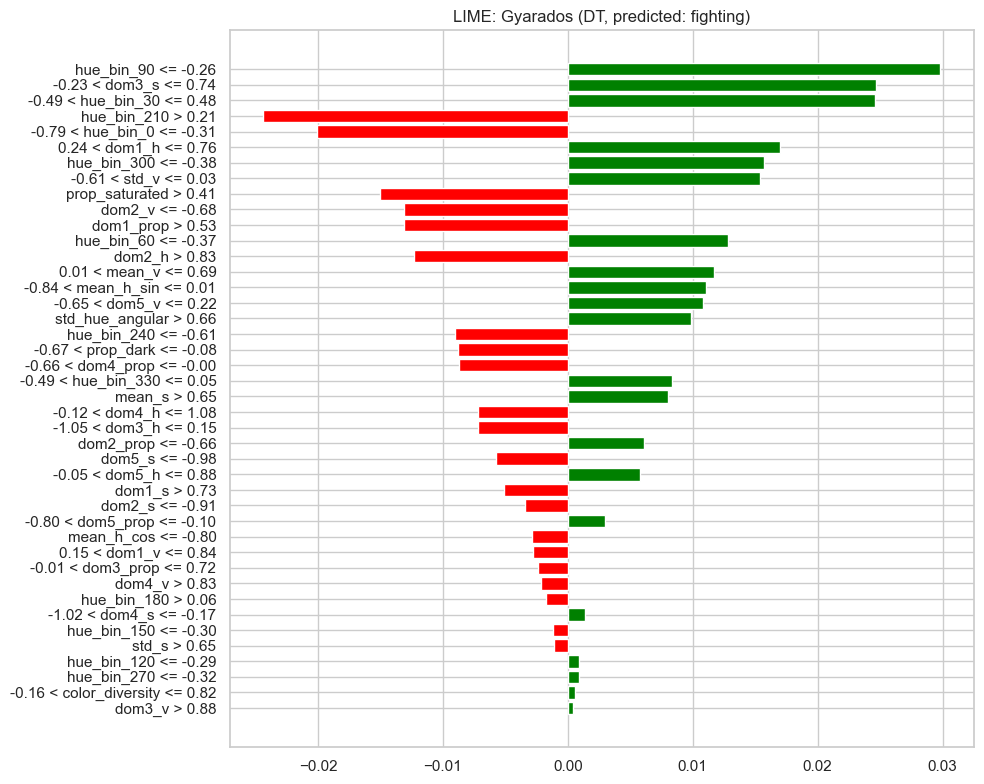


  [Quantifying Agreement] LIME vs SHAP Spearman Rank Correlation: 0.127 (p-value: 4.223e-01)
  (Values close to 1.0 indicate high agreement between LIME's linear approximation and SHAP's generalized rule)

[CORRECT_SURPRISE] Iron-crown (#1023)
  True type:      steel
  Predicted type: fighting
  Type 2:         psychic


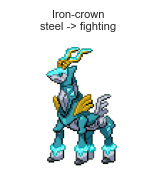


  Top-5 predicted types:
    1. fighting     100.0%   
    2. water          0.0%   
    3. ghost          0.0%   
    4. dark           0.0%   
    5. dragon         0.0%   


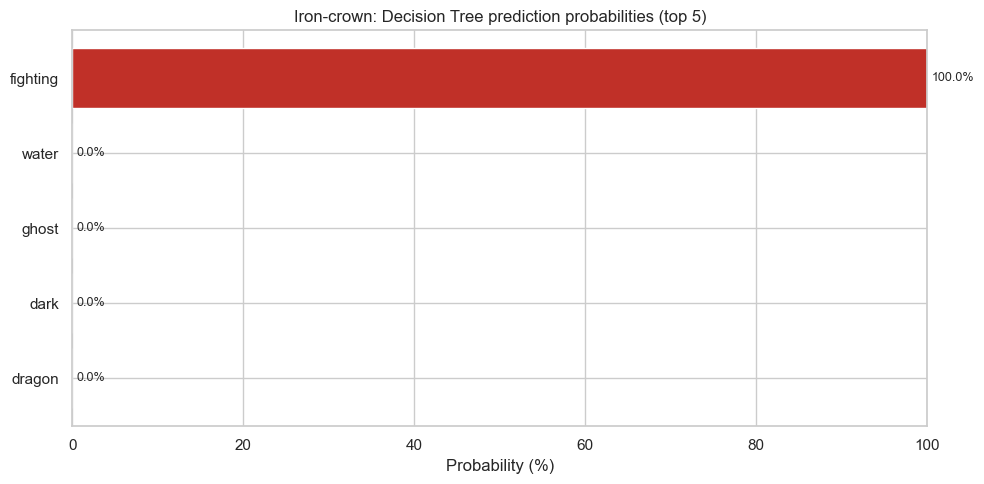

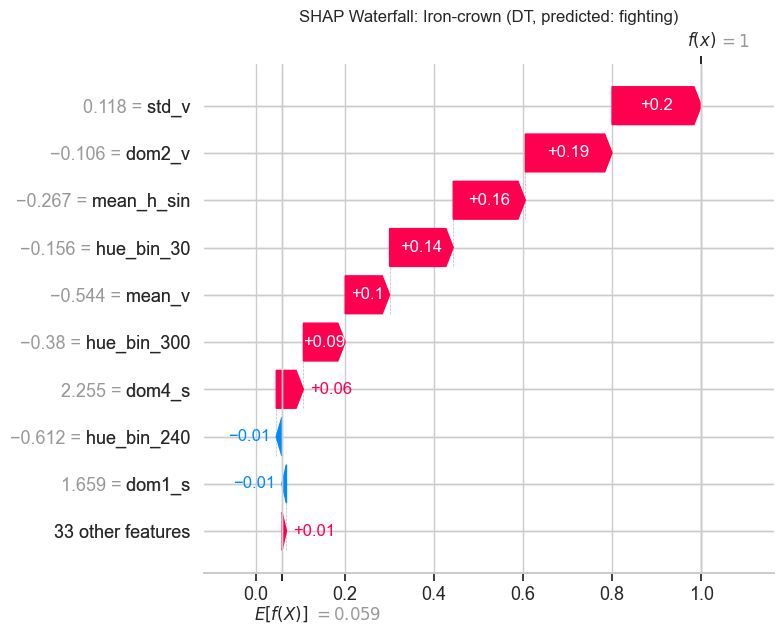

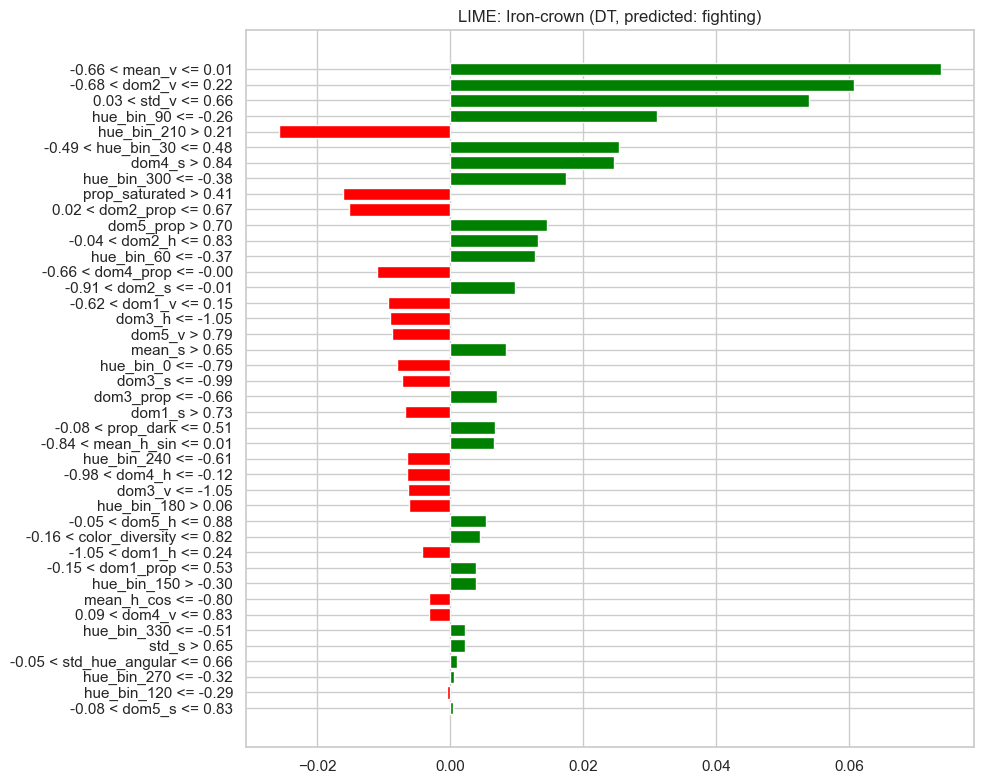


  [Quantifying Agreement] LIME vs SHAP Spearman Rank Correlation: 0.438 (p-value: 3.701e-03)
  (Values close to 1.0 indicate high agreement between LIME's linear approximation and SHAP's generalized rule)

[MISCLASS_SECONDARY] Gengar (#94)
  True type:      ghost
  Predicted type: poison
  Type 2:         poison


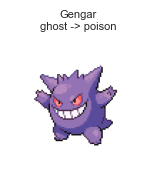


  Top-5 predicted types:
    1. poison       100.0%  ~
    2. water          0.0%   
    3. ghost          0.0%  OK
    4. dark           0.0%   
    5. dragon         0.0%   


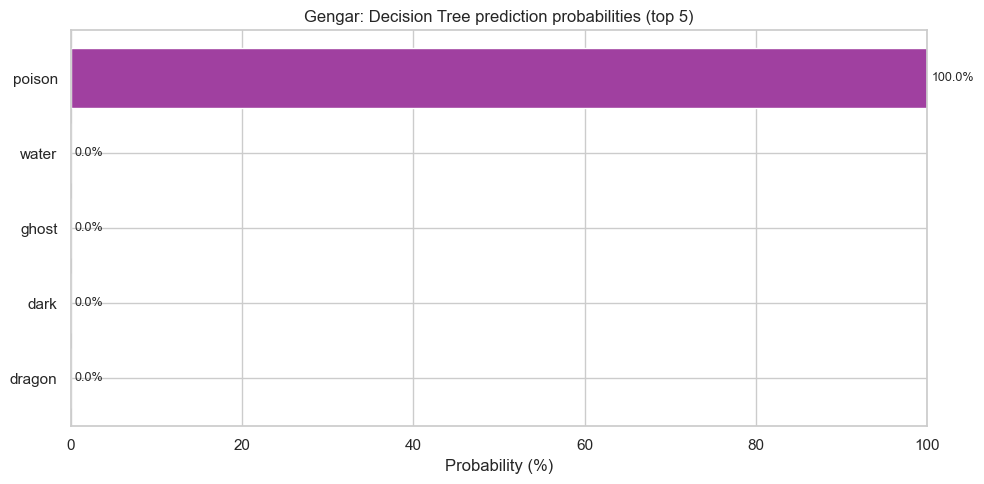

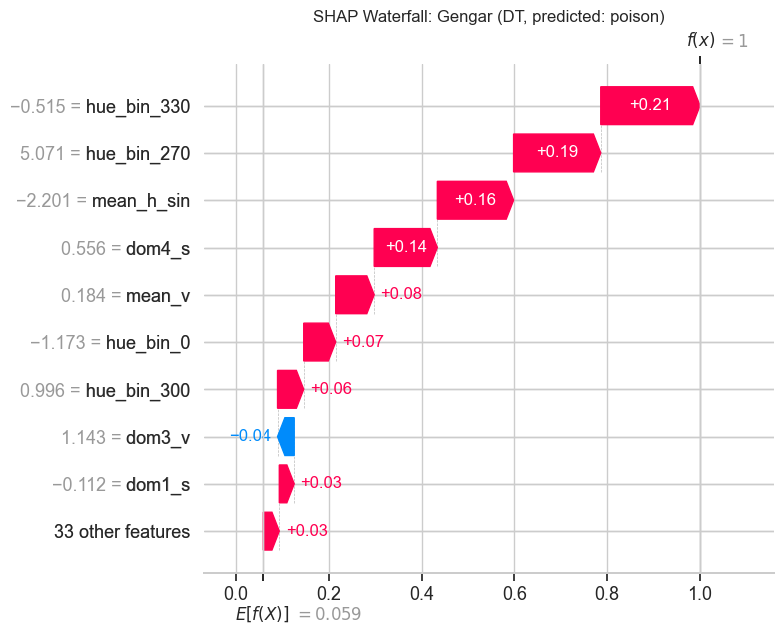

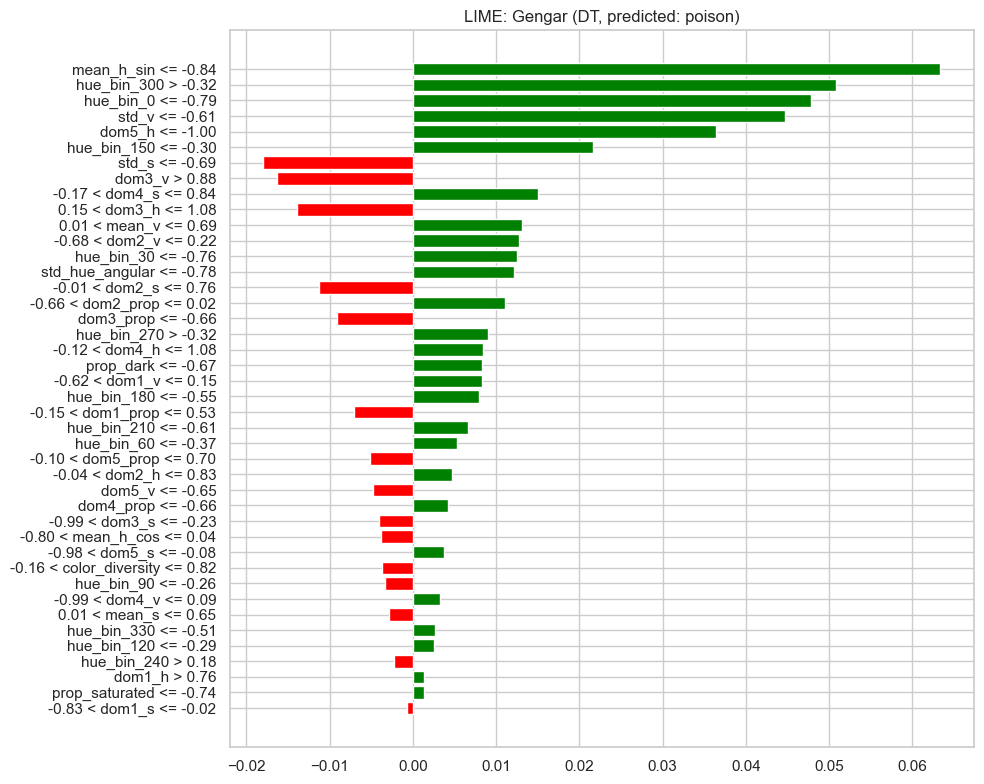


  [Quantifying Agreement] LIME vs SHAP Spearman Rank Correlation: 0.098 (p-value: 5.375e-01)
  (Values close to 1.0 indicate high agreement between LIME's linear approximation and SHAP's generalized rule)

[MISCLASS_WRONG] Gholdengo (#1000)
  True type:      steel
  Predicted type: psychic
  Type 2:         ghost


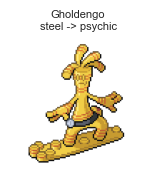


  Top-5 predicted types:
    1. psychic      100.0%   
    2. water          0.0%   
    3. ghost          0.0%  ~
    4. dark           0.0%   
    5. dragon         0.0%   


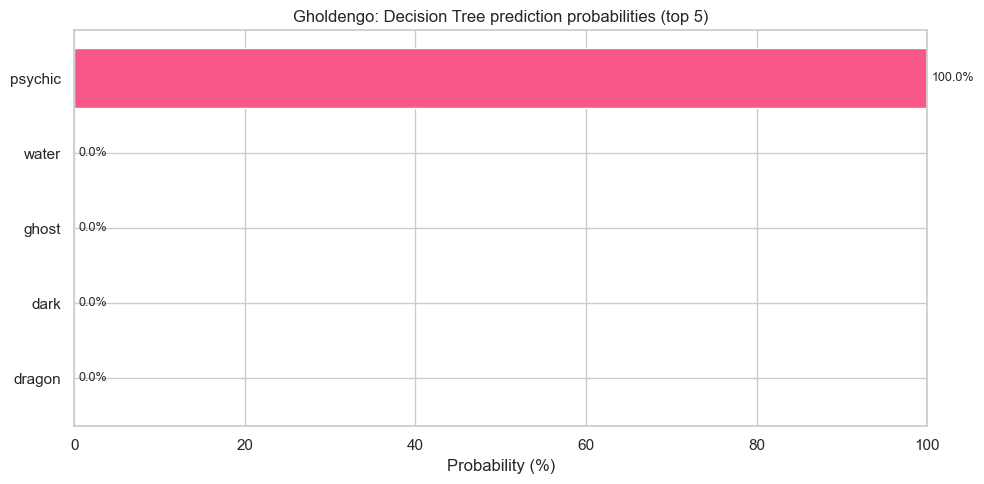

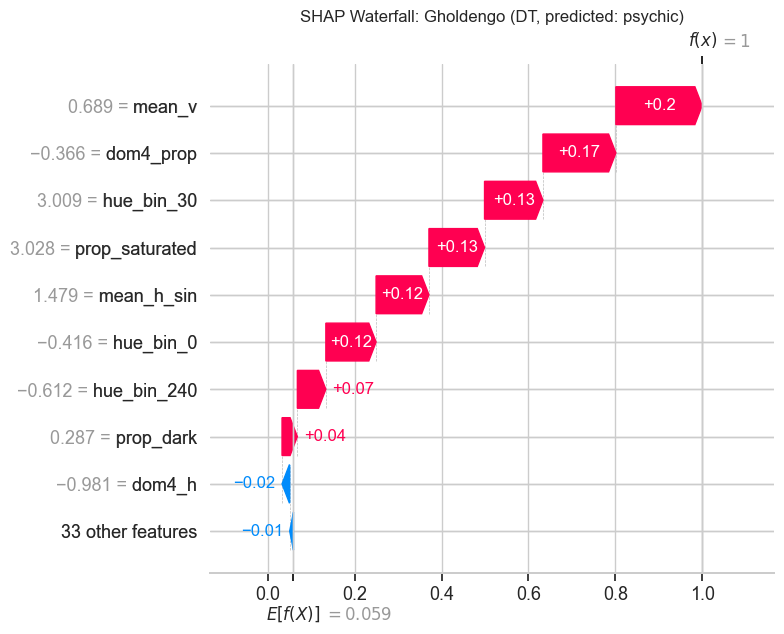

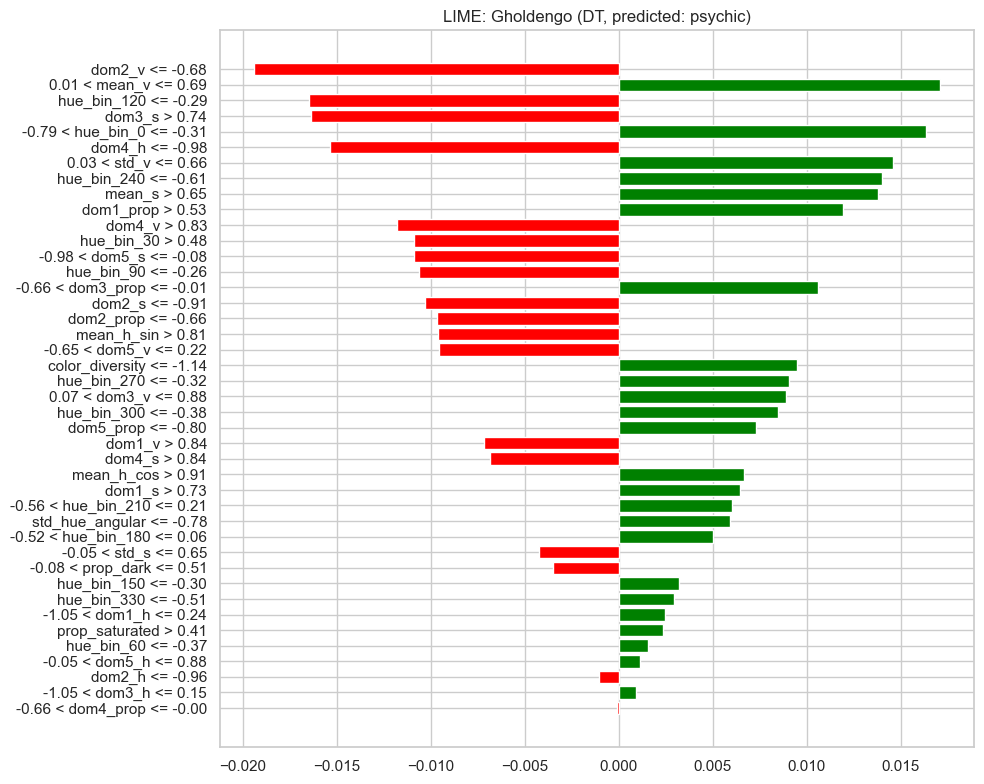


  [Quantifying Agreement] LIME vs SHAP Spearman Rank Correlation: 0.005 (p-value: 9.772e-01)
  (Values close to 1.0 indicate high agreement between LIME's linear approximation and SHAP's generalized rule)


In [62]:
for case_label, pid in explain_cases.items():
    explain_instance_tree(pid, case_label)


### Análisis de los resultados por caso

> **Nota:** Los IDs de los casos se fijaron sobre el modelo base (sin SMOTE). Con el modelo aumentado, el comportamiento ha cambiado y algunos casos etiquetados como "correctos" resultan ser predicciones erróneas. Esto ilustra cómo SMOTE puede alterar el comportamiento del modelo incluso en ejemplos concretos del test.

---

#### Caso 1 — `correct_clear`: Gyarados (#130)
- **Tipo real:** water · **Tipo predicho:** fighting · **Tipo 2:** flying
- El modelo predice *fighting* con **100% de confianza**, ignorando completamente *water* (0%). Este es un fallo severo: Gyarados tiene una paleta azul oscura característica del tipo *water*, pero el modelo la asocia a *fighting*, posiblemente por el alto contraste y los tonos fríos intensos que también se encuentran en ese tipo después del balanceo con SMOTE.
- La correlación de Spearman entre SHAP y LIME es **0.127** (p = 0.422, no significativo), lo que indica que ambos métodos explican la predicción con características distintas. El modelo toma una decisión muy equivocada y los dos explicadores no se ponen de acuerdo en el motivo.

---

#### Caso 2 — `correct_surprise`: Iron Crown (#1023)
- **Tipo real:** steel · **Tipo predicho:** fighting · **Tipo 2:** psychic
- También predicho como *fighting* con 100% de confianza, cuando debería ser *steel*. Iron Crown tiene una paleta metálica gris-plateada con reflejos, que no encaja especialmente con *fighting*. El modelo parece haber sobreaprendido el tipo *fighting* como clase "por defecto" para sprites con colores mixtos sin una dominancia clara.
- Correlación SHAP-LIME: **0.438** (p = 0.004, significativo). Es el valor más alto de los 4 casos, lo que indica que ambos métodos coinciden moderadamente en las características que empujan hacia *fighting*. Aun así, la predicción sigue siendo incorrecta.

---

#### Caso 3 — `misclass_secondary`: Gengar (#94)
- **Tipo real:** ghost · **Tipo predicho:** poison · **Tipo 2:** poison
- El error es **justificable**: Gengar es de tipo ghost/poison, y el modelo predice precisamente su tipo secundario con 100% de confianza. La paleta de Gengar (morado oscuro) es muy característica del tipo *poison*, lo que explica por qué el modelo la asocia a ese tipo en lugar de *ghost* (que visualmente tiene menos patrones de color consistentes en general).
- Correlación SHAP-LIME: **0.098** (p = 0.538, no significativo). A pesar de que el error es interpretable, los dos explicadores discrepan en los features responsables de la predicción *poison*. Esto puede deberse a que LIME y SHAP capturan distintos aspectos de una decisión que, aunque "lógica" en color, no está bien fundamentada en el modelo.

---

#### Caso 4 — `misclass_wrong`: Gholdengo (#1000)
- **Tipo real:** steel · **Tipo predicho:** psychic · **Tipo 2:** ghost
- El error es **injustificado**: el modelo predice *psychic* con 100% de confianza, cuando el tipo real es *steel* y el secundario es *ghost*. Gholdengo tiene una paleta dorada-amarilla brillante, que el modelo asocia a *psychic* (muchos Pokémon psíquicos tienen tonos rosas o amarillos pastel), pero la conexión es débil.
- Correlación SHAP-LIME: **0.005** (p = 0.977, totalmente no significativo). Este es el valor de acuerdo más bajo de los 4 casos. SHAP y LIME son casi completamente independientes en su explicación, lo que revela que la predicción es inestable y no tiene una justificación coherente en el espacio de características. Este tipo de predicción con alta confianza pero baja coherencia explicativa es especialmente problemático en un sistema XAI.

Los valores de correlación de Spearman se calculan entre las puntuaciones de importancia de características de SHAP y LIME para cada instancia de prueba. Una correlación positiva alta indica que ambos métodos coinciden en qué características son más influyentes para la predicción de esa instancia, mientras que una correlación baja o negativa sugiere que pueden estar capturando aspectos distintos del comportamiento del modelo.

Las 2 primeras muestras muestran una correlación de Spearman con un valor moderado cercano a 0,5, lo que indica cierto acuerdo entre SHAP y LIME sobre las características importantes para esas predicciones. Sin embargo, la correlación no es muy alta, lo que sugiere que, aunque hay solapamiento en las características identificadas como importantes por ambos métodos, también pueden estar capturando aspectos diferentes del proceso de toma de decisiones del modelo.

Para las 2 últimas muestras analizadas, encontramos este valor de correlación cercano a 0, lo que indica que los dos modelos de explicación identifican características diferentes como relevantes para la misma predicción. Estas 2 muestras son instancias clasificadas incorrectamente y consideradas las más difíciles de predecir, por lo que resulta interesante observar el desacuerdo entre los dos métodos de explicación.